# Traffic Safety Knowledge Graph Saxony – Analyse

Führt die in Kapitel 6/7 der Dokumentation beschriebenen SPARQL-Anfragen live gegen den lokalen Fuseki-Triplestore aus und visualisiert die Ergebnisse.

Voraussetzung: Fuseki läuft (Podman-Container) und das Dataset `traffic-safety` ist befüllt (siehe Kapitel 4).

Der Code in diesem Notebook wurde mit Unterstützung von Claude (Anthropic) erstellt, anschließend manuell geprüft und getestet.

In [ ]:
# pip install SPARQLWrapper pandas matplotlib --break-system-packages
from pathlib import Path
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt

FUSEKI_ENDPOINT = "http://localhost:3030/traffic-safety/query"
QUERIES_DIR = Path("../queries")  

def load_query(folder: str) -> str:
    return (QUERIES_DIR / f"{folder}.rq").read_text(encoding="utf-8")

def run_query(query: str) -> pd.DataFrame:
    sparql = SPARQLWrapper(FUSEKI_ENDPOINT)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()
    rows = [
        {k: v["value"] for k, v in row.items()}
        for row in results["results"]["bindings"]
    ]
    return pd.DataFrame(rows)

## Anfrage 1: PKW-Bestand pro 1.000 Einwohner (Top 20)

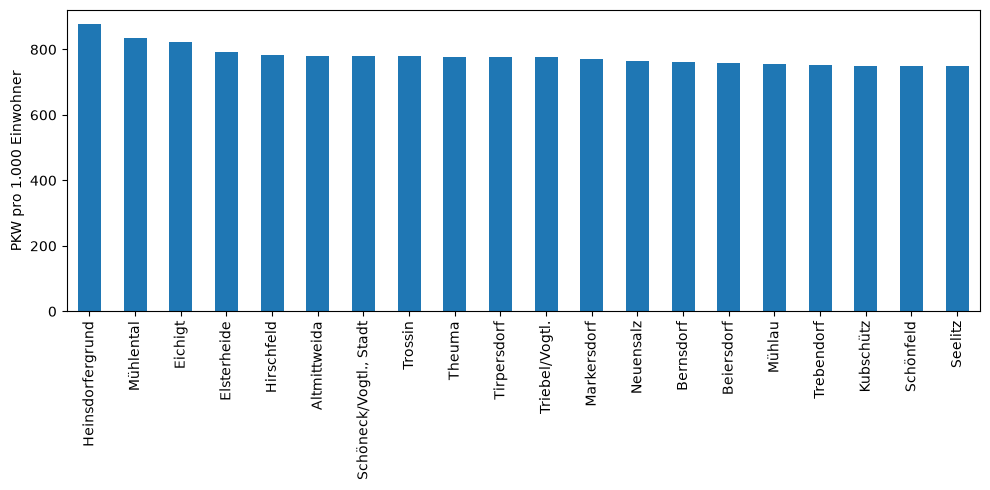

In [9]:
query1 = load_query("pkw_bestand")
df1 = run_query(query1)
df1["pkw_pro_1000_ew"] = df1["pkw_pro_1000_ew"].astype(float)

df1.plot.bar(x="name", y="pkw_pro_1000_ew", legend=False, figsize=(10, 5))
plt.ylabel("PKW pro 1.000 Einwohner")
plt.xlabel("")
plt.tight_layout()
plt.show()

Die Gemeinden mit dem höchsten PKW-Bestand pro 1.000 Einwohner liegen mit Werten um 750–880 überwiegend im ländlichen Raum. Bei kleinen Einwohnerzahlen jedoch kann bereits eine geringe Differenz im absoluten PKW-Bestand die Kennzahl deutlich verschieben. Die Rangfolge ist daher entsprechend vorsichtig zu interpretieren.

## Anfrage 2: Blitzerdichte je Gemeindefläche (Top 20)

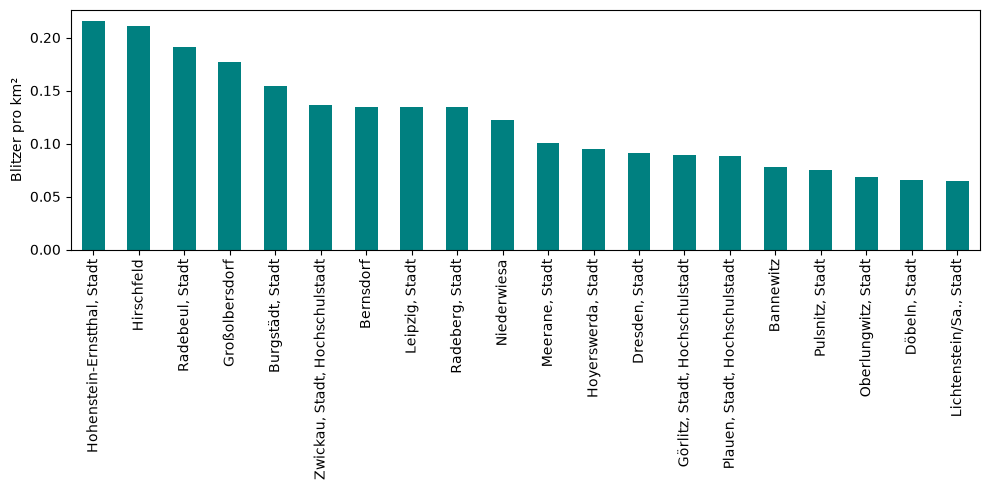

In [10]:
query2 = load_query("blitzerdichte")
df2 = run_query(query2)
df2["blitzer_pro_km2"] = df2["blitzer_pro_km2"].astype(float)

df2.plot.bar(x="name", y="blitzer_pro_km2", legend=False, figsize=(10, 5), color="teal")
plt.ylabel("Blitzer pro km²")
plt.xlabel("")
plt.tight_layout()
plt.show()

Hohenstein-Ernstthal führt mit rund 0,21 Messstellen pro km² vor Hirschfeld und Radebeul. Auffällig ist, dass unter den Top 20 sowohl kleine Gemeinden (darunter Hirschfeld) als auch große Städte (z. B. Leipzig, Dresden) vertreten sind. Die Blitzerdichte hängt also nicht unmittelbar mit der Gemeindegröße zusammen.

## Anfrage 3: Geografische Verteilung der Unfallschwere

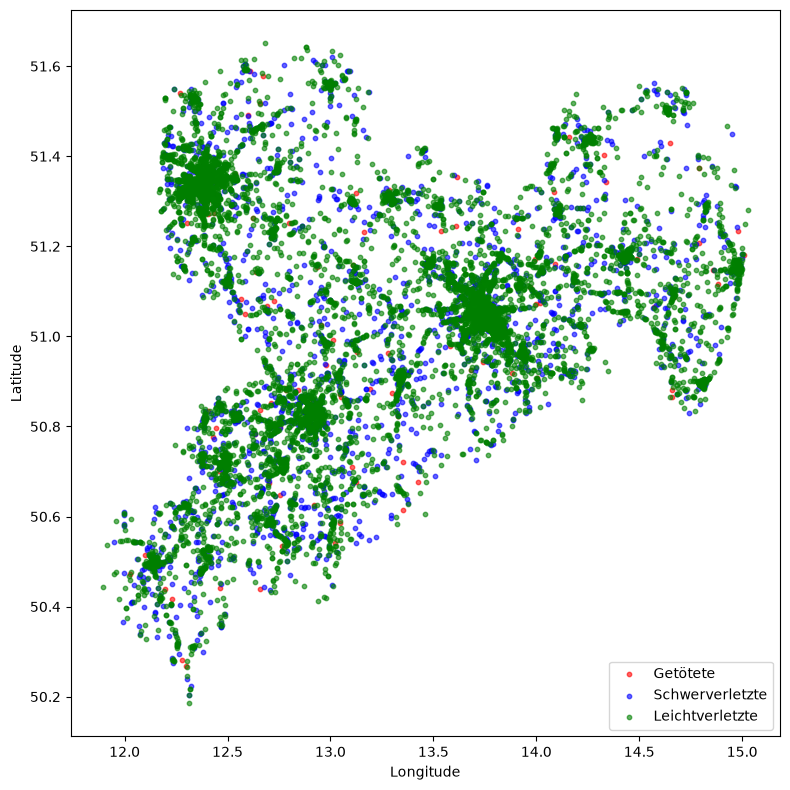

In [11]:
query3 = load_query("geoverteilung")
df3 = run_query(query3)
df3["latitude"] = df3["latitude"].astype(float)
df3["longitude"] = df3["longitude"].astype(float)

labels = {"1": "Getötete", "2": "Schwerverletzte", "3": "Leichtverletzte"}
colors = {"1": "red", "2": "blue", "3": "green"}

fig, ax = plt.subplots(figsize=(8, 8))
for code, group in df3.groupby("accidentCategoryCode"):
    ax.scatter(group["longitude"], group["latitude"], s=10, alpha=0.6,
               label=labels.get(code, code), color=colors.get(code))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.tight_layout()
plt.show()

Die räumliche Verteilung der 12.724 Unfälle folgt sichtbar dem sächsischen Straßennetz. Getötete (rot) treten deutlich seltener auf als Schwer- und Leichtverletzte und sind über das gesamte Bundesland verteilt, ohne dass sich eine klare regionale Häufung erkennen lässt.

## Anfrage 4: Beteiligung von PKW und Krafträdern nach Unfallschwere
(Flaggschiff-Anfrage, ausführlich in Kapitel 6 der Dokumentation beschrieben)

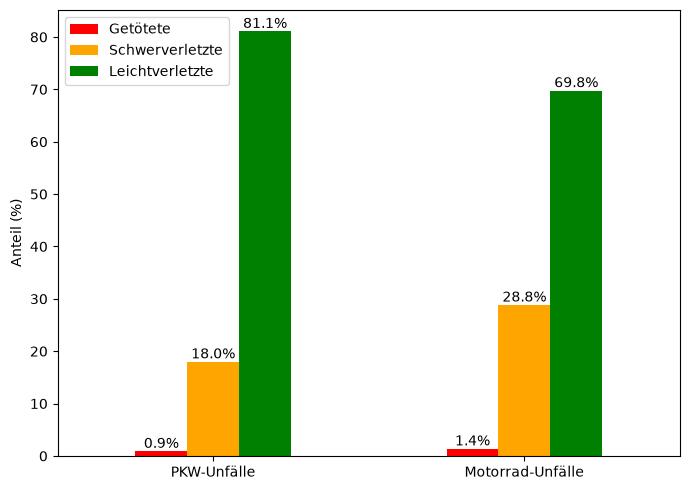

In [ ]:
query4 = load_query("fahrzeugart")
df4 = run_query(query4)
df4["pkw"] = df4["pkw"].astype(float)
df4["motorrad"] = df4["motorrad"].astype(float)
df4["label"] = df4["accidentCategoryCode"].map(labels)

df4["pkw_anteil"] = df4["pkw"] / df4["pkw"].sum() * 100
df4["motorrad_anteil"] = df4["motorrad"] / df4["motorrad"].sum() * 100

order = ["Get\u00f6tete", "Schwerverletzte", "Leichtverletzte"]
pivot = df4.set_index("label")[["pkw_anteil", "motorrad_anteil"]].T
pivot.index = ["PKW-Unf\u00e4lle", "Motorrad-Unf\u00e4lle"]
pivot = pivot[order]

ax = pivot.plot.bar(figsize=(7, 5), color=["red", "orange", "green"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.ylabel("Anteil (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

Bei Unfällen mit Kraftrad-Beteiligung liegt der Anteil an Getöteten (1,4 %) und Schwerverletzten (28,8 %) jeweils höher als bei PKW-Beteiligung (0,9 % bzw. 18,0 %). Kradfahrer tragen bei einem Unfall also relativ häufiger schwere Verletzungen davon als PKW-Insassen.

## Anfrage 5: Blitzerdichte im Verhältnis zur Unfallrate

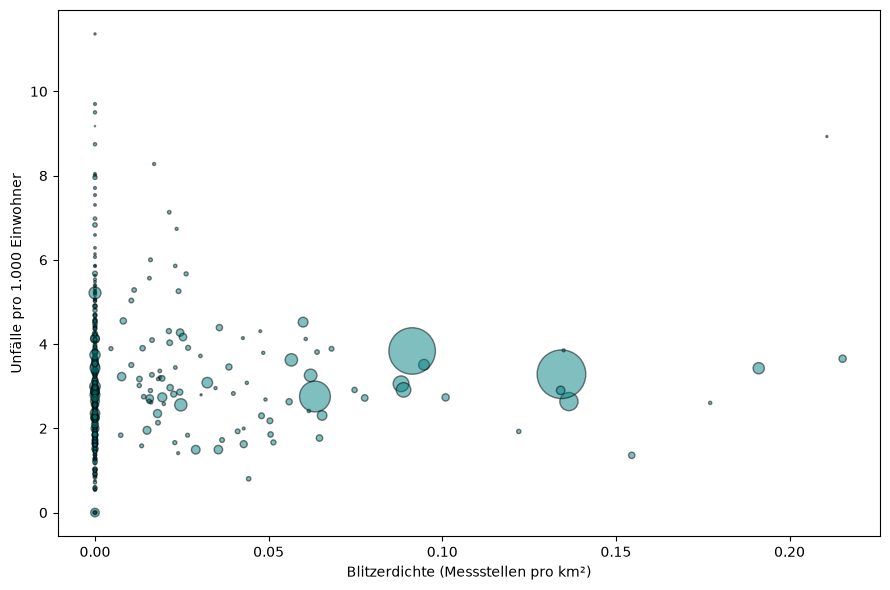

In [13]:
query5 = load_query("blitzer_unfallrate")
df5 = run_query(query5)
df5["blitzerdichte"] = df5["blitzerdichte"].astype(float)
df5["unfallrate"] = df5["unfallrate"].astype(float)
df5["population"] = df5["population"].astype(float)

plt.figure(figsize=(9, 6))
plt.scatter(df5["blitzerdichte"], df5["unfallrate"],
            s=df5["population"] / 500, alpha=0.5, color="teal", edgecolor="black")
plt.xlabel("Blitzerdichte (Messstellen pro km²)")
plt.ylabel("Unfälle pro 1.000 Einwohner")
plt.tight_layout()
plt.show()

Die Blasengröße visualisiert die Einwohnerzahl der jeweiligen Gemeinde. Von den 418 Gemeinden verfügen 319 über keine stationäre Geschwindigkeitsmessstelle und liegen entsprechend bei einer Blitzerdichte von 0. Ein eindeutiger Zusammenhang zwischen Blitzerdichte und Unfallrate lässt sich anhand dieser Daten demnach nicht feststellen.

## Zusammenfassung

Von den 418 sächsischen Gemeinden verfügen 101 über mindestens eine stationäre Geschwindigkeitsmessstelle, insgesamt wurden 273 Messstellen und 12.724 Unfälle aus dem Jahr 2025 erfasst. Die Fragestellung, ob ein Zusammenhang zwischen der Dichte stationärer Messstellen und der Unfallrate einer Gemeinde besteht, lässt sich anhand der vorliegenden Daten nicht bestätigen. Deutlicher fällt der Unterschied bei der Unfallschwere nach Fahrzeugart aus: Kradfahrer sind bei einem Unfall relativ häufiger von schweren oder tödlichen Verletzungen betroffen als PKW-Insassen.